[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nils-holmberg/de-code/blob/main/jnb/data_analysis_ailund.ipynb)

# Introduction

This notebook uses the QoG Basic cross-sectional dataset to illustrate a multivariate model of human development. For licensing reasons, the dataset is not redistributed here; instead, the code downloads the CSV directly from the official QoG data repository at render time.

Dataset citation in APA 7 format:

Dahlberg, S., Sundström, A., Holmberg, S., Rothstein, B., Alvarado Pachon, N., Saidi Phiri, V., Chen, C., & Liu, Z. (2026). *The Quality of Government Basic Dataset, Version Jan26*. University of Gothenburg: The Quality of Government Institute. https://www.gu.se/en/quality-government. https://doi.org/10.18157/qogbasjan26

The dependent variable is `undp_hdi`, the Human Development Index. The model uses three theoretically relevant predictors:

- `icrg_qog`: a continuous quality of government indicator. Better institutional quality should be associated with better development outcomes.
- `wdi_region`: a multinomial World Bank region variable. Region captures broad historical, economic, and geopolitical context.
- `bmr_dem`: a binary democracy indicator. Democratic accountability may influence public investment and welfare responsiveness.

The proposed model is:

```text
Human development = quality of government + world region + democracy
```

## Model Diagram

[![](https://mermaid.ink/img/pako:eNqVU1tr2zAU_itCoZCCk0m-xIlWAqV52GCMbYUWVvdBsZRYxJbMsZzWDfnvk5M4l7UvlcHoHOm7nCNpg1MjJGZ4CbzM0I8_iUZuCAUytcroXWafq-r5ftOt5nlTqQo93cynv0AKlVoDFTILlNUF10jItcxNWUhtb77Mp897_HveLnuaXV2h71rIUrqftuiBg-LzXFanHWpN-79rnivbtIJLs5agW6Xr8z1-_9FALhDIpRO7WAr6M1mYFHjaXHelHaRn74TPnK_pU1vvtw8rfP6P6c5ovS_00joaDKYt1YXXj5LBZdLZ6hQc-093ZOjeNrnSy8PZuECeDmah8pz1FpP28yoLZiVZL03Tw3wgeJVxAN4wFKHonKL1eEDvxhEdBIGXmtwA6xFCLiH-5yHBZyHiaExQQgQ9Qvx5SKNRh3JkZ42acVhJQLcA5qVrGOq7G6ZSWTliDhZxi8jhgrjl1f1OjXjU81En4ax0nXtRwmbML1-_Jhp77tUogZmFWnq4kFDwNsSbli7BNpOFTDBzU-GMJDjRW4cpuf5rTNHBwNTLDLMFzysX1aXgVs4Ud0_ttKW9lXBnam0xo2RHgdkGv7oo8IfxeBxTGoXxOGo7gRvMonDoExL4lE7iiEzi0Wjr4bedKhlOwpCQUTShcRyOQhpu_wFM_jpl?type=png)](https://mermaid.live/edit#pako:eNqVU1tr2zAU_itCoZCCk0m-JdFKoDQPG4yxrdDC6j4olhKL2JI5ltO6If99chLnsvalMhjp6HyXcyRtcGqExAwvgZcZ-vEn0cgNoUCmVhm9i-xjVT3fJ91qnjeVqtDTzXz6C6RQqTVQIbNAWV1wjYRcy9yUhdT25st8-rzHv-ftoqfZ1RX6roUspftpix44KD7PZXXKUGva_13zXNmmFVyatQTdKl2f5_j9RwO5QCCXTuxiK-jPZGFS4Glz3ZV2kJ69Ez5zvqZPbb3fPqzw-T-mO6P1vtBL62gwmLZUF14_CgaXQWerU3DsP92RoXvb5EovD2fjFvJ0MAuV56y3mLSfV1kwK8l6aZoe5gPBq4wD8IahCEXnFK3HA3o3juggCLzU5AZYjxByCfE_Dwk-CxFHY4ISIugR4s9DGsUdypGdNWrGYSUB3QKYl65hqO9umEpl5Yg5WMQtIocL4rZX9zs14lHPR52Es9J17kUJmzG_fP2aaOy5V6MEZhZq6eFCQsHbJd60dAm2mSxkgpmbCmckwYneOkzJ9V9jig4Gpl5mmC14XrlVXQpu5Uxx99SKYxTaawl3ptYWs2hHgdkGv2JGA384Go9HlEbhaBy1ncCNywmHPiGBT-lkFJHJKI63Hn7bqZLhJAwJiaMojsc0ID7d_gNVmTp5)

## Data Import and Variable Selection

In [ ]:
import pandas as pd

url = "https://www.qogdata.pol.gu.se/data/qog_bas_cs_jan26.csv"

variables = {
    "cname": "Country",
    "ccodealp": "ISO alpha-3 country code",
    "undp_hdi": "Human Development Index",
    "icrg_qog": "Quality of government",
    "wdi_region": "World Bank region",
    "bmr_dem": "Democracy indicator",
}

df = pd.read_csv(url)
model_df = df[list(variables)].copy()
model_df = model_df.rename(columns=variables)

model_df["World Bank region"] = model_df["World Bank region"].astype("category")
model_df["Democracy indicator"] = model_df["Democracy indicator"].map(
    {0: "Non-democracy", 1: "Democracy"}
).astype("category")

complete_model_df = model_df.dropna().copy()

summary = pd.DataFrame(
    {
        "measure": [
            "Rows in full dataset",
            "Variables in full dataset",
            "Rows after selecting model variables",
            "Complete cases for proposed model",
            "Countries in complete-case model data",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            model_df.shape[0],
            complete_model_df.shape[0],
            complete_model_df["Country"].nunique(),
        ],
    }
)

display(summary)
display(model_df.head())
display(model_df.describe(include="all"))

,measure,value
0,Rows in full dataset,194
1,Variables in full dataset,320
2,Rows after selecting model variables,194
3,Complete cases for proposed model,137
4,Countries in complete-case model data,137


,Country,ISO alpha-3 country code,Human Development Index,Quality of government,World Bank region,Democracy indicator
0,Afghanistan,AFG,0.495,NaN,4.0,Non-democracy
1,Albania,ALB,0.806,0.442130,2.0,Democracy
2,Algeria,DZA,0.761,0.434028,4.0,Non-democracy
3,Andorra,AND,0.893,NaN,2.0,Democracy
4,Angola,AGO,0.615,0.418981,7.0,Non-democracy


,Country,ISO alpha-3 country code,Human Development Index,Quality of government,World Bank region,Democracy indicator
count,194,194,190.000000,139.000000,192.0,193
unique,194,194,NaN,NaN,7.0,2
top,Afghanistan,AFG,NaN,NaN,2.0,Democracy
freq,1,1,NaN,NaN,52.0,117
mean,NaN,NaN,0.736953,0.542732,NaN,NaN
std,NaN,NaN,0.150338,0.199414,NaN,NaN
min,NaN,NaN,0.385000,0.055556,NaN,NaN
25%,NaN,NaN,0.622000,0.416667,NaN,NaN
50%,NaN,NaN,0.761000,0.500000,NaN,NaN
75%,NaN,NaN,0.852750,0.667824,NaN,NaN


## Model Specification

The corresponding regression formula is:

```text
undp_hdi ~ icrg_qog + C(wdi_region) + bmr_dem
```

In the modified dataset above, this means estimating human development as a function of quality of government, region, and democracy status.

# 1. Descriptive statistics


## use subheadings

Add new text cells like this to write a few sentences explaining the analysis in the associated code cell. Feel free to add subheadings, but don't change the main sections of the notebook. Make note of and explain the findings of your analysis. Visualize your data!

=== DESCRIPTIVE STATISTICS ===

Continuous Variables Summary:
       Human Development Index  Quality of government
count               190.000000             139.000000
mean                  0.736953               0.542732
std                   0.150338               0.199414
min                   0.385000               0.055556
25%                   0.622000               0.416667
50%                   0.761000               0.500000
75%                   0.852750               0.667824
max                   0.967000               1.000000

Categorical Variables Summary:
        World Bank region Democracy indicator
count               192.0                 193
unique                7.0                   2
top                   2.0           Democracy
freq                 52.0                 117

Missing Value Counts per Variable:
Human Development Index     4
Quality of government      55
World Bank region           2
Democracy indicator         1
dtype: int64


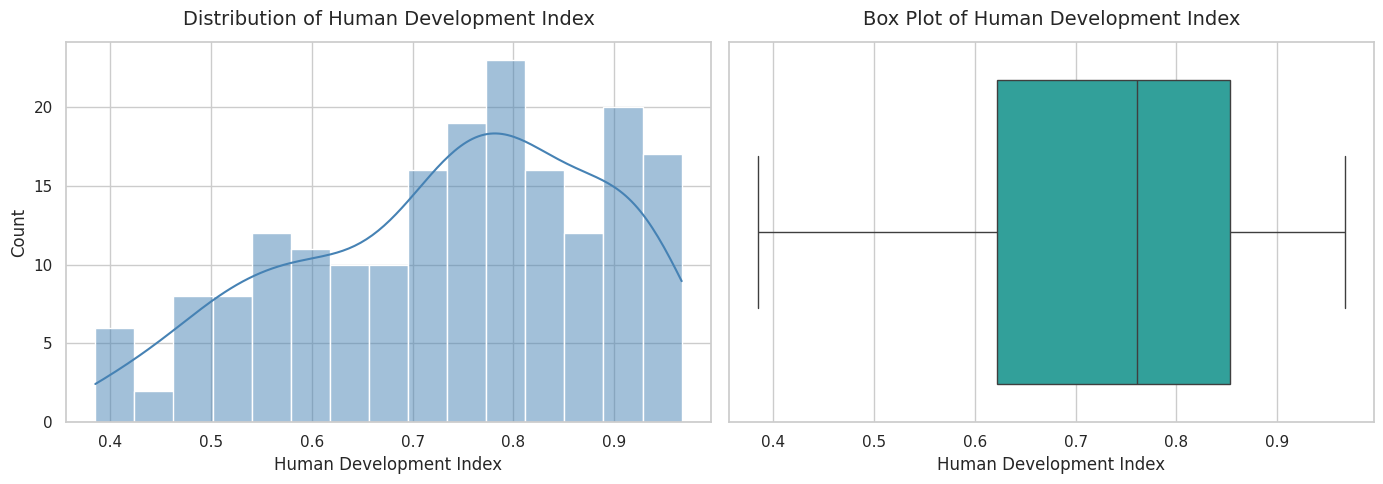

In [ ]:
# code cell 1.1, keep this comment, edit content but do not add more code cells

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual theme for the plots
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. DESCRIPTIVE STATISTICS
# ==============================================================================
print("=== DESCRIPTIVE STATISTICS ===")

# Summary statistics for continuous variables
print("\nContinuous Variables Summary:")
print(model_df[["Human Development Index", "Quality of government"]].describe())

# Summary statistics for categorical variables
print("\nCategorical Variables Summary:")
print(
    model_df[["World Bank region", "Democracy indicator"]].describe(
        include="category"
    )
)

# Missing value analysis
print("\nMissing Value Counts per Variable:")
print(
    model_df[
        [
            "Human Development Index",
            "Quality of government",
            "World Bank region",
            "Democracy indicator",
        ]
    ].isna().sum()
)

# ==============================================================================
# 2. VISUALIZATIONS OF THE DEPENDENT VARIABLE
# ==============================================================================
# Create a multi-panel figure for the distribution of the Human Development Index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Panel: Histogram with Kernel Density Estimate (KDE)
sns.histplot(
    data=model_df,
    x="Human Development Index",
    kde=True,
    bins=15,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title(
    "Distribution of Human Development Index", fontsize=14, pad=12
)
axes[0].set_xlabel("Human Development Index", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

# Right Panel: Box Plot to inspect quantiles and potential outliers
sns.boxplot(
    data=model_df, x="Human Development Index", color="lightseagreen", ax=axes[1]
)
axes[1].set_title("Box Plot of Human Development Index", fontsize=14, pad=12)
axes[1].set_xlabel("Human Development Index", fontsize=12)

# Adjust layout to prevent label truncation and save the figure
plt.tight_layout()
plt.savefig(
    "dependent_variable_distribution.png", dpi=300, bbox_inches="tight"
)

In [ ]:
# code cell 1.2, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 1.3, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 1.4, keep this comment, edit content but do not add more code cells


# 2. Data transformations

In [ ]:
# code cell 2.1, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 2.2, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 2.3, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 2.4, keep this comment, edit content but do not add more code cells


# 3. Bivariate analysis


In [ ]:
# code cell 3.1, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 3.2, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 3.3, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 3.4, keep this comment, edit content but do not add more code cells


# 4. Hypothesis testing


In [ ]:
# code cell 4.1, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 4.2, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 4.3, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 4.4, keep this comment, edit content but do not add more code cells


# 5. Multivariate analysis


In [ ]:
# code cell 5.1, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 5.2, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 5.3, keep this comment, edit content but do not add more code cells


In [ ]:
# code cell 5.4, keep this comment, edit content but do not add more code cells
